In [24]:
include("CRD_STA.jl")
include("LST_BEK.jl")
using Plots
using LinearAlgebra
using NonlinearEigenproblems
using ProgressMeter
using DelimitedFiles

In [109]:
num = 1
c = 0.03
N = 199
omega = 0
be = 0.114
R = 32
Ro = 1
Co = 0
A0,A1,A2,A3,A4 = KEB_SpatialMode.KEB_LST_ALL("Bodewadt.txt",N,omega,be,R,Ro,Co)
nep = PEP([A0,A1,A2,A3,A4]); #Create a PEP object
sc=10
nep1 = shift_and_scale(nep,scale=sc);
mult_scale = norm(nep1.A[end]);
nep2 = PEP(nep1.A ./ mult_scale);
eigval,eigvec = iar(nep2,σ=c,neigs=num,maxit=500);
eigval = sc*eigval

1-element Vector{ComplexF64}:
 0.34267347272825466 + 4.767850676391805e-5im

In [114]:
readdlm("Ekman.txt")

20000×6 Matrix{Float64}:
  0.0         -4.95503e-29  -2.00173e-29  …  -1.0           1.0
  0.00150008   2.24798e-6   -0.00149783      -0.997002      0.999998
  0.00300015   8.98291e-6   -0.00299116      -0.994009      0.999991
  0.00450023   2.01913e-5   -0.00448         -0.99102       0.99998
  0.0060003    3.58598e-5   -0.00596437      -0.988035      0.999964
  0.00750038   5.59749e-5   -0.00744426   …  -0.985056      0.999944
  0.00900045   8.05231e-5   -0.00891968      -0.98208       0.999919
  0.0105005    0.000109491  -0.0103906       -0.979109      0.999891
  0.0120006    0.000142866  -0.0118572       -0.976143      0.999857
  0.0135007    0.000180633  -0.0133192       -0.973181      0.999819
  ⋮                                       ⋱                 ⋮
 29.988        1.0           2.56542e-15     -2.13759e-13  -1.56075e-13
 29.9895       1.0           2.24476e-15     -2.13764e-13  -1.56067e-13
 29.991        1.0           1.92409e-15     -2.13769e-13  -1.56061e-13
 29.9925     

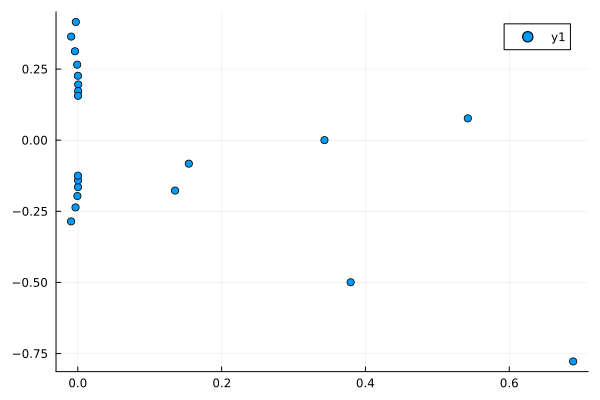

In [85]:
scatter(real(eigval),imag(eigval))